# Loan Default Prediction Model

Professional machine learning workflow for predicting loan default risk using the Home Credit Credit Risk Model Stability dataset.


# Business Problem

Banks and consumer finance companies must decide whether an applicant is likely to repay a loan before credit is issued. This decision is especially difficult for applicants with limited or thin credit history, where traditional scorecards may be less reliable. A poor risk decision can create two costly outcomes: approving borrowers who are likely to default, or rejecting creditworthy customers who could have been served responsibly.

# Business Objective

The objective of this notebook is to build a stable loan default prediction model that estimates the probability of default for each applicant. Accurate probability estimates help lenders improve approval decisions, price risk more effectively, allocate manual review capacity, and expand financial inclusion while maintaining portfolio quality.

# Dataset Overview

This project uses the Home Credit Credit Risk Model Stability dataset. The data is organized across multiple relational CSV files containing application records, bureau information, tax registry signals, previous applications, person-level details, deposit/debit-card activity, and other customer behavior attributes.

The target variable is `target`, where higher predicted probability indicates greater default risk. The notebook preserves the original data ingestion, feature engineering, cross-validation strategy, model choice, and submission-generation logic.


# Import Libraries


In [1]:
import gc
import os
import warnings
from datetime import datetime
from glob import glob
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from IPython.display import display
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold, TimeSeriesSplit, learning_curve

warnings.simplefilter(action="ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

IMAGE_DIR = Path("/kaggle/working/images")
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

print("Polars version:", pl.__version__)


Polars version: 1.35.2


In [2]:
ROOT = Path("/kaggle/input/competitions/home-credit-credit-risk-model-stability")
# ROOT = Path("./input")

TRAIN_DIR = ROOT / "csv_files" / "train"
TEST_DIR = ROOT / "csv_files" / "test"


In [3]:
TRAIN_DIR

PosixPath('/kaggle/input/competitions/home-credit-credit-risk-model-stability/csv_files/train')

# Data Cleaning

The cleaning pipeline standardizes column data types, converts date columns into numeric time-delta features, removes columns with excessive missingness, and excludes categorical variables that are either uninformative or too high-cardinality for the current model pipeline.

Missing values are handled by removing columns with more than 95% null values, while LightGBM handles remaining missing values natively during model training. The original notebook does not introduce a separate duplicate-removal step; after relational aggregation and joins, the modeling table is maintained at the application-level `case_id` grain. These choices are preserved to avoid changing model behavior.


## Data Type Standardization

The `Pipeline` class enforces consistent data types based on the dataset's column naming conventions. This is important because LightGBM handles numeric, categorical, and date-derived features differently, and inconsistent types can introduce silent modeling errors.


In [4]:
class Pipeline:
    """Utility methods for schema alignment, date handling, and column filtering."""

    @staticmethod
    def set_table_dtypes(df):
        """Cast columns to stable data types based on Home Credit suffix conventions."""
        for col in df.columns:
            if col in ["case_id", "WEEK_NUM", "num_group1", "num_group2"]:
                df = df.with_columns(pl.col(col).cast(pl.Int64))
            elif col in ["date_decision"]:
                df = df.with_columns(pl.col(col).cast(pl.Date))
            elif col[-1] in ("P", "A"):
                df = df.with_columns(pl.col(col).cast(pl.Float64))
            elif col[-1] in ("M",):
                df = df.with_columns(pl.col(col).cast(pl.String))
            elif col[-1] in ("D",):
                df = df.with_columns(pl.col(col).cast(pl.Date))
        return df

    @staticmethod
    def handle_dates(df):
        """Convert date columns into days relative to the application decision date."""
        for col in df.columns:
            if col[-1] in ("D",):
                df = df.with_columns(pl.col(col) - pl.col("date_decision"))
                df = df.with_columns(pl.col(col).dt.total_days())
        df = df.drop("date_decision", "MONTH")
        return df

    @staticmethod
    def filter_cols(df):
        """Remove sparse columns and categorical columns with unusable cardinality."""
        for col in df.columns:
            if col not in ["target", "case_id", "WEEK_NUM"]:
                isnull = df[col].is_null().mean()
                if isnull > 0.95:
                    df = df.drop(col)

        for col in df.columns:
            if (col not in ["target", "case_id", "WEEK_NUM"]) & (df[col].dtype == pl.String):
                freq = df[col].n_unique()
                if (freq == 1) | (freq > 200):
                    df = df.drop(col)
        return df


## Aggregation Strategy

Several source tables contain multiple historical records per applicant. The `Aggregator` class summarizes those records at the `case_id` level, preserving the original maximum-value aggregation strategy. This creates one modeling row per loan application while retaining signals from prior behavior.


In [5]:
class Aggregator:
    
    '''Generates aggregation expressions for numeric columns (identified by suffixes "P" or "A"). 
    It creates expressions to find the maximum value of these columns.'''
    
    @staticmethod
    def num_expr(df):
        cols = [col for col in df.columns if col[-1] in ("P", "A")]
        expr_max = [pl.max(col).alias(f"max_{col}") for col in cols]
        return expr_max

    '''Generates aggregation expressions for date columns (identified by suffix "D"). 
    It creates expressions to find the maximum value of these columns.'''
    
    @staticmethod
    def date_expr(df):
        cols = [col for col in df.columns if col[-1] in ("D",)]
        expr_max = [pl.max(col).alias(f"max_{col}") for col in cols]
        return expr_max

    '''Generates aggregation expressions for string columns (identified by suffix "M"). 
    It creates expressions to find the maximum value of these columns.'''
    
    @staticmethod
    def str_expr(df):
        cols = [col for col in df.columns if col[-1] in ("M",)]
        expr_max = [pl.max(col).alias(f"max_{col}") for col in cols]
        return expr_max

    '''Generates aggregation expressions for other types of columns (identified by suffixes "T" or "L"). 
    It creates expressions to find the maximum value of these columns.'''
    
    @staticmethod
    def other_expr(df):
        cols = [col for col in df.columns if col[-1] in ("T", "L")]
        expr_max = [pl.max(col).alias(f"max_{col}") for col in cols]
        return expr_max

    '''Generates aggregation expressions for columns related to grouping 
    (columns containing "num_group"). It creates expressions to find the maximum value of these columns.'''
    
    @staticmethod
    def count_expr(df):
        cols = [col for col in df.columns if "num_group" in col]
        expr_max = [pl.max(col).alias(f"max_{col}") for col in cols]
        return expr_max

    '''Combines all the aggregation expressions from the other methods into a single list of expressions.'''
    
    @staticmethod
    def get_exprs(df):
        exprs = Aggregator.num_expr(df) + \
                Aggregator.date_expr(df) + \
                Aggregator.str_expr(df) + \
                Aggregator.other_expr(df) + \
                Aggregator.count_expr(df)
        return exprs


## Single-File Reader

`read_file` loads one CSV file, applies the standardized schema, and aggregates historical tables when the table depth requires it.


In [6]:
def read_file(path, depth=None):
    df = pl.read_csv(path)
    df = df.pipe(Pipeline.set_table_dtypes)

    if depth in [1, 2]:
        df = df.group_by("case_id").agg(Aggregator.get_exprs(df))
    return df

## Multi-File Reader

`read_files` applies the same logic to file families matched by a path pattern. This keeps train and test ingestion consistent across table groups.


In [7]:
def read_files(regex_path, depth=None):
    chunks = []
    for path in glob(str(regex_path)):
        chunks.append(pl.read_csv(path).pipe(Pipeline.set_table_dtypes))
    df = pl.concat(chunks, how="vertical_relaxed")
    if depth in [1, 2]:
        df = df.group_by("case_id").agg(Aggregator.get_exprs(df))
    return df

# Feature Engineering


## Feature Engineering Rationale

The existing feature engineering logic is preserved exactly. It adds calendar context from the decision date, joins related applicant history tables, and converts date fields into relative day offsets. These transformations are useful because default risk is often influenced by recency, seasonality, previous credit behavior, and applicant-level financial history.


In [8]:
def feature_eng(df_base, depth_0, depth_1, depth_2):
    """Create application-level features and merge all relational data sources."""
    df_base = (
        df_base
        .with_columns(
            month_decision=pl.col("date_decision").dt.month(),
            weekday_decision=pl.col("date_decision").dt.weekday(),
        )
    )
    for i, df in enumerate(depth_0 + depth_1 + depth_2):
        df_base = df_base.join(df, how="left", on="case_id", suffix=f"_{i}")
    df_base = df_base.pipe(Pipeline.handle_dates)
    return df_base


def to_pandas(df_data, cat_cols=None):
    """Convert Polars data to Pandas and preserve categorical feature types."""
    df_data = df_data.to_pandas()
    if cat_cols is None:
        cat_cols = list(df_data.select_dtypes("object").columns)
    df_data[cat_cols] = df_data[cat_cols].astype("category")
    return df_data, cat_cols


# Dataset Loading

The training and test datasets are loaded from the same relational table structure. The original table selection and merge order are preserved to maintain compatibility with the existing model behavior.


In [9]:
data_store = {
    "df_base": read_file(TRAIN_DIR / "train_base.csv"),
    "depth_0": [
        read_file(TRAIN_DIR / "train_static_cb_0.csv"),
        read_files(TRAIN_DIR / "train_static_0_*.csv"),
    ],
    "depth_1": [
        read_files(TRAIN_DIR / "train_applprev_1_*.csv", 1),
        read_file(TRAIN_DIR / "train_tax_registry_a_1.csv", 1),
        read_file(TRAIN_DIR / "train_tax_registry_b_1.csv", 1),
        read_file(TRAIN_DIR / "train_tax_registry_c_1.csv", 1),
        read_file(TRAIN_DIR / "train_credit_bureau_b_1.csv", 1),
        read_file(TRAIN_DIR / "train_other_1.csv", 1),
        read_file(TRAIN_DIR / "train_person_1.csv", 1),
        read_file(TRAIN_DIR / "train_deposit_1.csv", 1),
        read_file(TRAIN_DIR / "train_debitcard_1.csv", 1),
    ],
    "depth_2": [
        read_file(TRAIN_DIR / "train_credit_bureau_b_2.csv", 2),
    ]
}

In [10]:
pwd

'/kaggle/working'

In [11]:
df_train = feature_eng(**data_store) # Unpacking the contents of the dictionary using ** Operator
print("train data shape:\t", df_train.shape)

train data shape:	 (1526659, 376)


In [12]:
data_store = {
    "df_base": read_file(TEST_DIR / "test_base.csv"),
    "depth_0": [
        read_file(TEST_DIR / "test_static_cb_0.csv"),
        read_files(TEST_DIR / "test_static_0_*.csv"),
    ],
    "depth_1": [
        read_files(TEST_DIR / "test_applprev_1_*.csv", 1),
        read_file(TEST_DIR / "test_tax_registry_a_1.csv", 1),
        read_file(TEST_DIR / "test_tax_registry_b_1.csv", 1),
        read_file(TEST_DIR / "test_tax_registry_c_1.csv", 1),
        read_file(TEST_DIR / "test_credit_bureau_b_1.csv", 1),
        read_file(TEST_DIR / "test_other_1.csv", 1),
        read_file(TEST_DIR / "test_person_1.csv", 1),
        read_file(TEST_DIR / "test_deposit_1.csv", 1),
        read_file(TEST_DIR / "test_debitcard_1.csv", 1),
    ],
    "depth_2": [
        read_file(TEST_DIR / "test_credit_bureau_b_2.csv", 2),
    ]
}

In [13]:
df_test = feature_eng(**data_store) # Unpacking the contents of the dictionary using ** Operator
print("test data shape:\t", df_test.shape)

test data shape:	 (10, 375)


# Train and Test Dataset

After feature generation, the same column filtering rules are applied to training data. The test set is then aligned to the training schema, excluding only the target column.


In [14]:
df_train = df_train.pipe(Pipeline.filter_cols)
df_test = df_test.select([col for col in df_train.columns if col != "target"])

print("train data shape:\t", df_train.shape)
print("test data shape:\t", df_test.shape)

train data shape:	 (1526659, 260)
test data shape:	 (10, 259)


In [15]:
df_train, cat_cols = to_pandas(df_train)
df_test, cat_cols = to_pandas(df_test, cat_cols)

# Exploratory Data Analysis

This section provides lightweight business-oriented checks after the original preprocessing and schema alignment steps. The visuals are diagnostic only and do not alter the modeling dataset, feature engineering, train-test split, or model configuration.


/tmp/ipykernel_16/2049580639.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Non-default (0)", "Default (1)"])


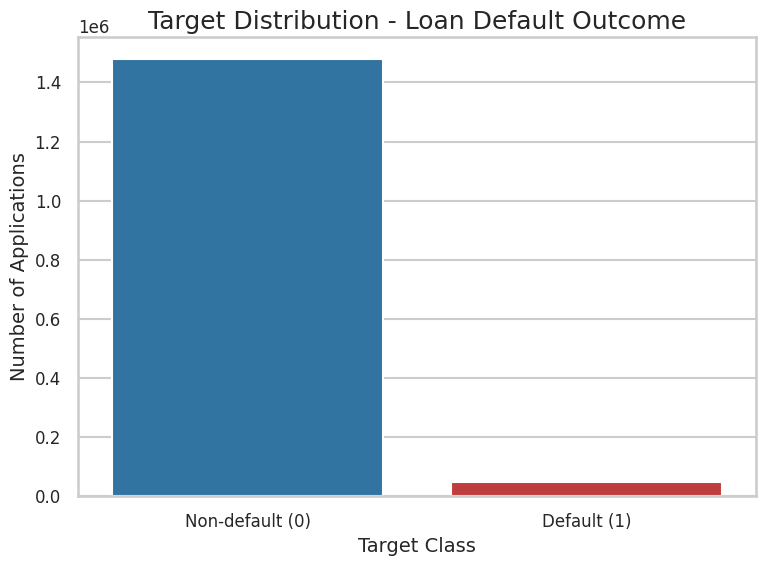

Observed default rate: 3.1437%


In [16]:
target_counts = df_train["target"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=target_counts.index.astype(str), y=target_counts.values, palette=["#1f77b4", "#d62728"], ax=ax)
ax.set_title("Target Distribution - Loan Default Outcome")
ax.set_xlabel("Target Class")
ax.set_ylabel("Number of Applications")
ax.set_xticklabels(["Non-default (0)", "Default (1)"])
plt.tight_layout()
fig.savefig(IMAGE_DIR / "target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

default_rate = df_train["target"].mean()
print(f"Observed default rate: {default_rate:.4%}")


## Business Insight: Target Distribution

The target distribution shows the balance between non-default and default cases. Loan default datasets are commonly imbalanced because most borrowers repay, while the minority default class drives a large share of portfolio losses.

**Business implication:** Accuracy alone can be misleading when defaults are rare, because a model can appear accurate while missing many risky borrowers.

**Recommended action:** Prioritize ranking and minority-class metrics such as ROC-AUC, precision, recall, and precision-recall performance when evaluating credit-risk models.


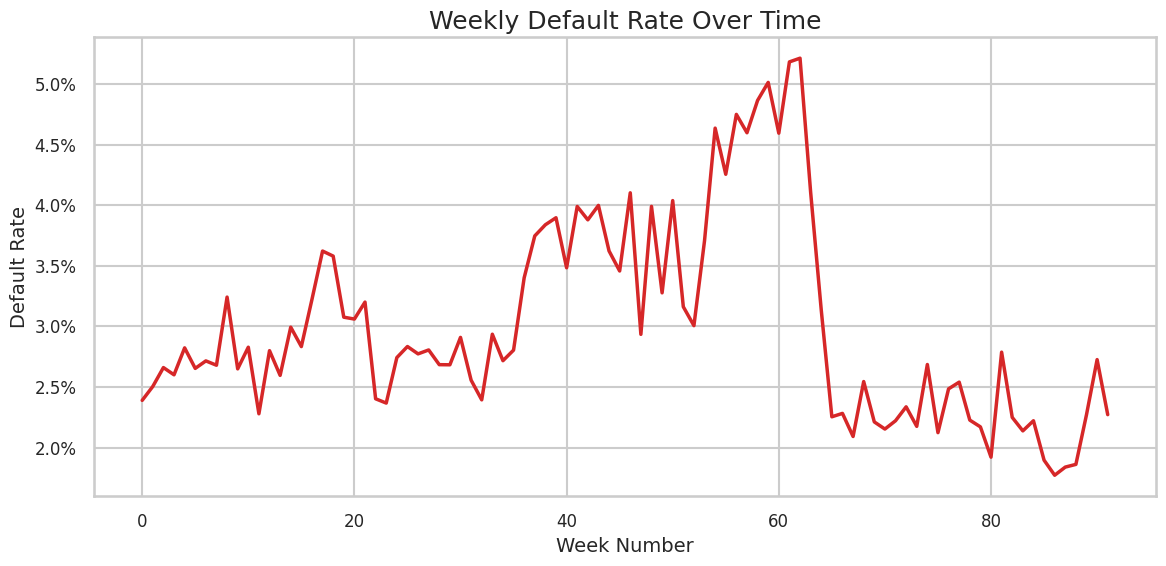

In [17]:
weekly_default_rate = (
    df_train
    .groupby("WEEK_NUM", observed=True)["target"]
    .agg(["mean", "count"])
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(weekly_default_rate["WEEK_NUM"], weekly_default_rate["mean"], color="#d62728", linewidth=2.5)
ax1.set_title("Weekly Default Rate Over Time")
ax1.set_xlabel("Week Number")
ax1.set_ylabel("Default Rate")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.1%}"))
plt.tight_layout()
fig.savefig(IMAGE_DIR / "weekly_default_rate.png", dpi=300, bbox_inches="tight")
plt.show()


## Business Insight: Weekly Default Rate

The weekly default-rate trend checks whether risk levels shift over time. Changes can reflect macroeconomic conditions, acquisition-channel changes, policy updates, or seasonal borrower behavior.

**Business implication:** Time instability can cause a model trained on older applicants to underperform on newer cohorts.

**Recommended action:** Monitor model performance and default rates by booking week in production, and retrain or recalibrate when recent cohorts drift materially from training patterns.


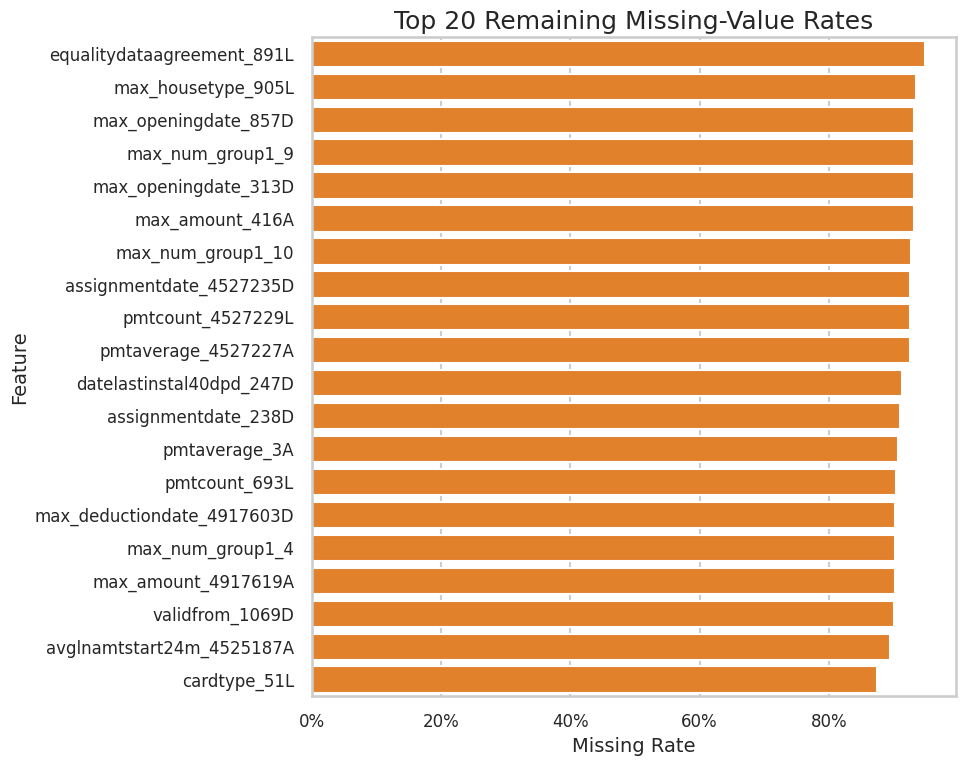

,feature,missing_rate
0,equalitydataagreement_891L,0.948890
1,max_housetype_905L,0.933962
2,max_openingdate_857D,0.931165
3,max_num_group1_9,0.931150
4,max_openingdate_313D,0.931150
5,max_amount_416A,0.931150
6,max_num_group1_10,0.926787
7,assignmentdate_4527235D,0.924687
8,pmtcount_4527229L,0.924687
9,pmtaverage_4527227A,0.924687


In [18]:
missing_profile = (
    df_train
    .drop(columns=["target", "case_id", "WEEK_NUM"], errors="ignore")
    .isna()
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
missing_profile.columns = ["feature", "missing_rate"]

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=missing_profile, x="missing_rate", y="feature", color="#ff7f0e", ax=ax)
ax.set_title("Top 20 Remaining Missing-Value Rates")
ax.set_xlabel("Missing Rate")
ax.set_ylabel("Feature")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
plt.tight_layout()
fig.savefig(IMAGE_DIR / "missing_values_top20.png", dpi=300, bbox_inches="tight")
plt.show()

display(missing_profile)


## Business Insight: Missing Values

The missing-value profile highlights features that remain sparse after the original high-missingness filter. In credit data, missingness can be informative because absent bureau, tax, or transaction records may reflect customer history depth or product eligibility.

**Business implication:** Remaining missingness should be monitored because shifts in upstream data availability can change model scores even when borrower risk has not changed.

**Recommended action:** Add production data-quality checks for missing-rate drift, especially for high-importance variables and fields supplied by external data providers.


In [19]:
# Release intermediate table references after feature assembly.
del data_store
gc.collect()


2843

In [20]:
class VotingModel(BaseEstimator, RegressorMixin):
    def __init__(self, estimators):
        super().__init__()
        self.estimators = estimators

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        y_preds = [estimator.predict(X) for estimator in self.estimators]
        return np.mean(y_preds, axis=0)

    def predict_proba(self, X):
        y_preds = [estimator.predict_proba(X) for estimator in self.estimators]
        return np.mean(y_preds, axis=0)

In [21]:
X = df_train.drop(columns=["target", "case_id","WEEK_NUM"])
y = df_train["target"]
weeks = df_train["WEEK_NUM"]

In [22]:
'''import optuna
from sklearn.model_selection import cross_validate
from lightgbm import LGBMClassifier

def objective(trial):
    max_depth = trial.suggest_int('max_depth', 3, 30)
    n_estimators = trial.suggest_int('n_estimators', 1, 1000)
    gamma = trial.suggest_float('gamma', 0, 1)
    reg_alpha = trial.suggest_float('reg_alpha', 0, 1)
    reg_lambda = trial.suggest_float('reg_lambda', 0, 1)
    min_child_weight = trial.suggest_int('min_child_weight', 0, 10)
    subsample = trial.suggest_float('subsample', 0, 1)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0, 1)
    learning_rate = trial.suggest_float('learning_rate', 0, 1)
    
#     print('Training the model with', X.shape[1], 'features')
    
#       LightGBM
    params = {'learning_rate': learning_rate,
              'n_estimators': n_estimators,
              'max_depth': max_depth,
              'lambda_l1': reg_alpha,
              'lambda_l2': reg_lambda,
              'colsample_bytree': colsample_bytree, 
              'subsample': subsample,    
              'min_child_samples': min_child_weight,
              'class_weight': 'balanced'}
    
    clf = LGBMClassifier(**params, verbose = -1, verbosity = -1)
    
    cv_results = cross_validate(clf,X,y, cv=5, scoring='accuracy')
    
    validation_score = np.mean(cv_results['test_score'])
    
    return validation_score'''

"import optuna\nfrom sklearn.model_selection import cross_validate\nfrom lightgbm import LGBMClassifier\n\ndef objective(trial):\n    max_depth = trial.suggest_int('max_depth', 3, 30)\n    n_estimators = trial.suggest_int('n_estimators', 1, 1000)\n    gamma = trial.suggest_float('gamma', 0, 1)\n    reg_alpha = trial.suggest_float('reg_alpha', 0, 1)\n    reg_lambda = trial.suggest_float('reg_lambda', 0, 1)\n    min_child_weight = trial.suggest_int('min_child_weight', 0, 10)\n    subsample = trial.suggest_float('subsample', 0, 1)\n    colsample_bytree = trial.suggest_float('colsample_bytree', 0, 1)\n    learning_rate = trial.suggest_float('learning_rate', 0, 1)\n    \n#     print('Training the model with', X.shape[1], 'features')\n    \n#       LightGBM\n    params = {'learning_rate': learning_rate,\n              'n_estimators': n_estimators,\n              'max_depth': max_depth,\n              'lambda_l1': reg_alpha,\n              'lambda_l2': reg_lambda,\n              'colsample_by

In [23]:
'''study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials= 2)'''

'study = optuna.create_study(direction="maximize")\nstudy.optimize(objective, n_trials= 2)'

# Model Development

The model uses LightGBM, a gradient boosting framework that performs well on structured/tabular data and can handle a mix of numerical and categorical predictors. The validation strategy remains `StratifiedGroupKFold`, grouped by `WEEK_NUM`, so validation folds preserve class balance while respecting time-based grouping.

The original model hyperparameters are unchanged: each fold trains `lgb.LGBMClassifier()` with LightGBM defaults, early stopping, and logging callbacks. Fold models are combined with the existing `VotingModel` wrapper.


In [24]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=False)

fitted_models = []
cv_scores = []
oof_pred = pd.Series(index=X.index, dtype=float)
oof_true = pd.Series(index=X.index, dtype=float)

for idx_train, idx_valid in cv.split(X, y, groups=weeks):
    X_train, y_train = X.iloc[idx_train], y.iloc[idx_train]
    X_valid, y_valid = X.iloc[idx_valid], y.iloc[idx_valid]

    print("Valid week range: ", (weeks.iloc[idx_valid].min(), weeks.iloc[idx_valid].max()))

    model = lgb.LGBMClassifier()
    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        callbacks=[lgb.log_evaluation(50), lgb.early_stopping(50)]
    )

    fitted_models.append(model)

    y_pred_valid = model.predict_proba(X_valid)[:, 1]
    auc_score = roc_auc_score(y_valid, y_pred_valid)
    cv_scores.append(auc_score)

    # Store out-of-fold predictions for unbiased evaluation visualizations.
    oof_pred.iloc[idx_valid] = y_pred_valid
    oof_true.iloc[idx_valid] = y_valid

model = VotingModel(fitted_models)
print("CV AUC scores: ", cv_scores)


Valid week range:  (3, 90)
[LightGBM] [Info] Number of positive: 37755, number of negative: 1183301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.071229 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 30534
[LightGBM] [Info] Number of data points in the train set: 1221056, number of used features: 256
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.030920 -> initscore=-3.444945
[LightGBM] [Info] Start training from score -3.444945
Training until validation scores don't improve for 50 rounds
[50]	valid_0's binary_logloss: 0.124105
[100]	valid_0's binary_logloss: 0.122318
Did not meet early stopping. Best iteration is:
[100]	valid_0's binary_logloss: 0.122318
Valid week range:  (0, 89)
[LightGBM] [Info] Number of positive: 38743, number of negative: 1182495
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of test

# Model Evaluation

The following section evaluates the model using out-of-fold validation predictions from the unchanged cross-validation process. This avoids creating a new train-test split while still providing an honest view of how the model generalizes to unseen validation folds.

Metrics are interpreted as follows:

- **Accuracy**: Overall share of correct default/non-default classifications at the selected threshold.
- **Precision**: Among applicants predicted as default risk, the share that actually defaulted.
- **Recall**: Among actual defaulters, the share identified by the model.
- **F1 Score**: Balance between precision and recall.
- **ROC-AUC**: Rank-ordering quality across all thresholds.
- **Average Precision**: Precision-recall performance, useful for imbalanced default data.


Out-of-fold evaluation metrics


,Metric,Value
0,Accuracy,0.9685
1,Precision,0.4740
2,Recall,0.0076
3,F1 Score,0.0150
4,ROC-AUC,0.8246
5,Average Precision,0.1552


              precision    recall  f1-score   support

           0       0.97      1.00      0.98   1478665
           1       0.47      0.01      0.01     47994

    accuracy                           0.97   1526659
   macro avg       0.72      0.50      0.50   1526659
weighted avg       0.95      0.97      0.95   1526659



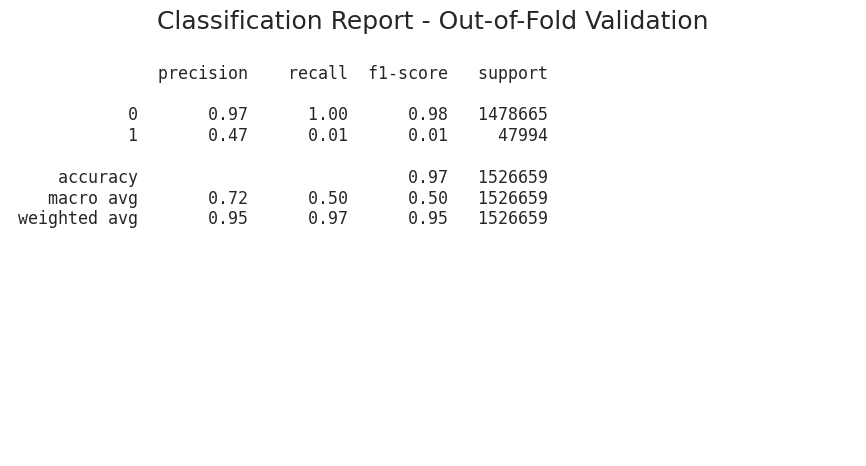

In [25]:
valid_mask = oof_pred.notna()
y_eval = oof_true[valid_mask].astype(int)
y_proba = oof_pred[valid_mask]
y_pred = (y_proba >= 0.5).astype(int)

metrics_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "Average Precision"],
    "Value": [
        accuracy_score(y_eval, y_pred),
        precision_score(y_eval, y_pred, zero_division=0),
        recall_score(y_eval, y_pred, zero_division=0),
        f1_score(y_eval, y_pred, zero_division=0),
        roc_auc_score(y_eval, y_proba),
        average_precision_score(y_eval, y_proba),
    ],
})

print("Out-of-fold evaluation metrics")
display(metrics_summary.style.format({"Value": "{:.4f}"}))

report_text = classification_report(y_eval, y_pred, zero_division=0)
print(report_text)

fig, ax = plt.subplots(figsize=(9, 5))
ax.axis("off")
ax.text(
    0.01,
    0.98,
    report_text,
    va="top",
    ha="left",
    family="monospace",
    fontsize=12,
)
ax.set_title("Classification Report - Out-of-Fold Validation", pad=20)
plt.tight_layout()
fig.savefig(IMAGE_DIR / "classification_report.png", dpi=300, bbox_inches="tight")
plt.show()


## Business Insight: Classification Metrics

The out-of-fold metrics summarize how the model behaves on validation applicants that were not used to train each fold model. In credit risk, ROC-AUC is especially important because lenders typically rank applicants by risk and choose operating thresholds based on portfolio strategy. Precision and recall show the trade-off between unnecessary interventions and missed defaults.

**Business implication:** The final lending policy should not rely on the default `0.5` threshold alone. The threshold should be tuned to the institution's loss tolerance, approval-rate targets, and manual review capacity.

**Recommended action:** Use the probability score as a risk-ranking tool, then define business-specific score bands for auto-approval, manual review, pricing adjustment, and decline decisions.


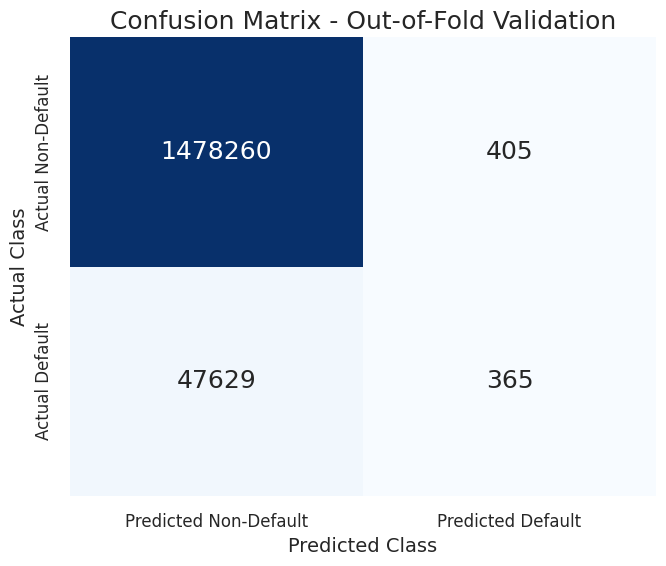

In [26]:
cm = confusion_matrix(y_eval, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Predicted Non-Default", "Predicted Default"],
    yticklabels=["Actual Non-Default", "Actual Default"],
    ax=ax,
)
ax.set_title("Confusion Matrix - Out-of-Fold Validation")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")
plt.tight_layout()
fig.savefig(IMAGE_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


## Business Insight: Confusion Matrix

The confusion matrix translates model probabilities into operational outcomes at a `0.5` threshold. False positives represent applicants flagged as risky who did not default, while false negatives represent risky applicants the model missed.

**Business implication:** False negatives can increase credit losses, while false positives can reduce customer acquisition and financial inclusion.

**Recommended action:** Choose a decision threshold based on expected loss, customer lifetime value, and the cost of manual review rather than using a generic threshold.


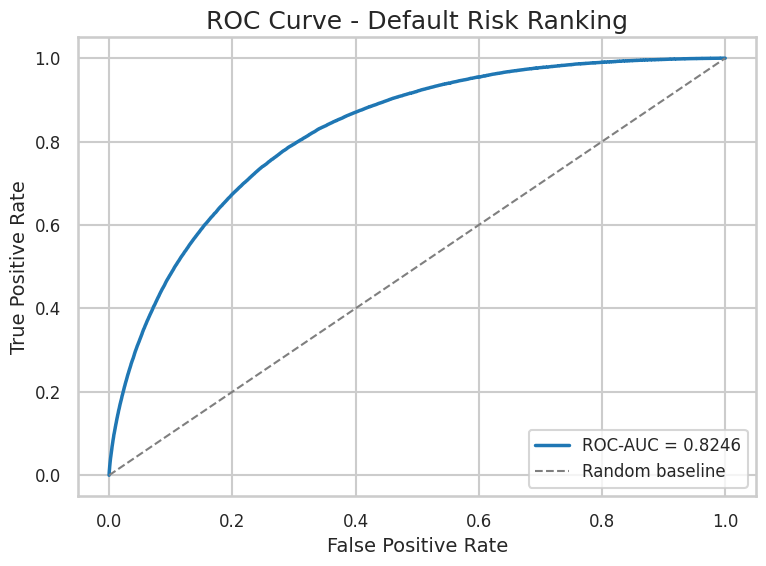

In [27]:
fpr, tpr, roc_thresholds = roc_curve(y_eval, y_proba)
roc_auc = roc_auc_score(y_eval, y_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color="#1f77b4", linewidth=2.5, label=f"ROC-AUC = {roc_auc:.4f}")
ax.plot([0, 1], [0, 1], color="#7f7f7f", linestyle="--", linewidth=1.5, label="Random baseline")
ax.set_title("ROC Curve - Default Risk Ranking")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(IMAGE_DIR / "roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()


## Business Insight: ROC Curve

The ROC curve shows how well the model separates defaulters from non-defaulters across every possible threshold. A stronger curve bends toward the upper-left corner, meaning more defaulters are identified while keeping false alarms lower.

**Business implication:** Strong ranking performance allows the lender to create more reliable risk tiers, even if the final approval threshold changes over time.

**Recommended action:** Use ROC-AUC for model comparison and scorecard monitoring, while selecting operating thresholds through business cost analysis.


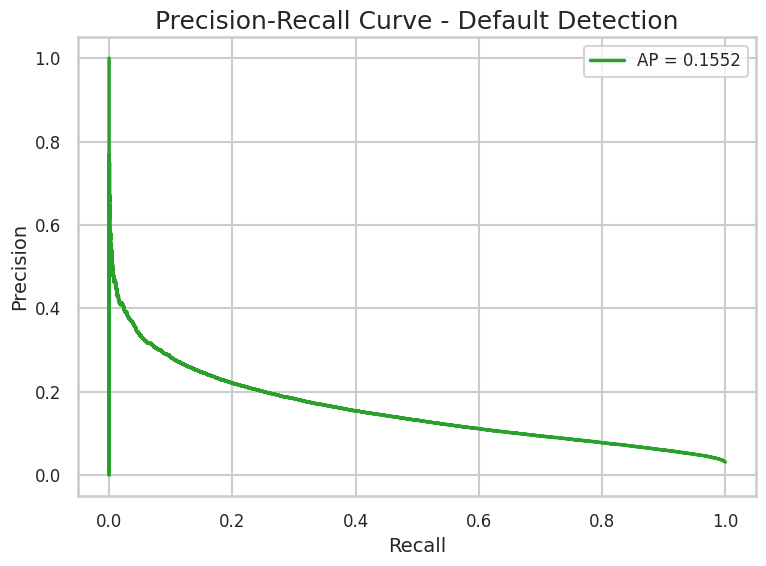

In [28]:
precision_values, recall_values, pr_thresholds = precision_recall_curve(y_eval, y_proba)
avg_precision = average_precision_score(y_eval, y_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_values, precision_values, color="#2ca02c", linewidth=2.5, label=f"AP = {avg_precision:.4f}")
ax.set_title("Precision-Recall Curve - Default Detection")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="upper right")
plt.tight_layout()
fig.savefig(IMAGE_DIR / "precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()


## Business Insight: Precision-Recall Curve

Default prediction is usually an imbalanced classification problem, so the precision-recall curve is a practical view of how many predicted high-risk applicants are truly risky at different recall levels.

**Business implication:** Higher recall can reduce missed defaults, but it may lower precision and increase the number of customers sent to manual review or rejected.

**Recommended action:** Select a recall target that matches risk appetite, then estimate staffing and customer-impact costs from the resulting precision level.


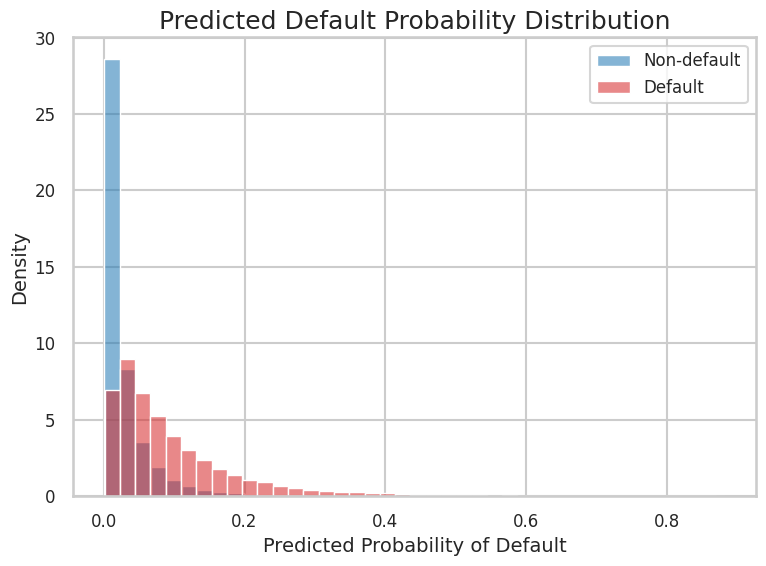

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(y_proba[y_eval == 0], bins=40, stat="density", color="#1f77b4", alpha=0.55, label="Non-default", ax=ax)
sns.histplot(y_proba[y_eval == 1], bins=40, stat="density", color="#d62728", alpha=0.55, label="Default", ax=ax)
ax.set_title("Predicted Default Probability Distribution")
ax.set_xlabel("Predicted Probability of Default")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
fig.savefig(IMAGE_DIR / "probability_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


## Business Insight: Probability Distribution

This chart compares model score distributions for actual defaulters and non-defaulters. Better separation means the model can distinguish high-risk applicants from lower-risk applicants more clearly.

**Business implication:** Overlap between the two distributions identifies applicants where the model is less certain and where automated decisions may be riskier.

**Recommended action:** Route middle-score applicants to manual review or request additional documentation, while automating decisions for the clearest low-risk and high-risk bands.


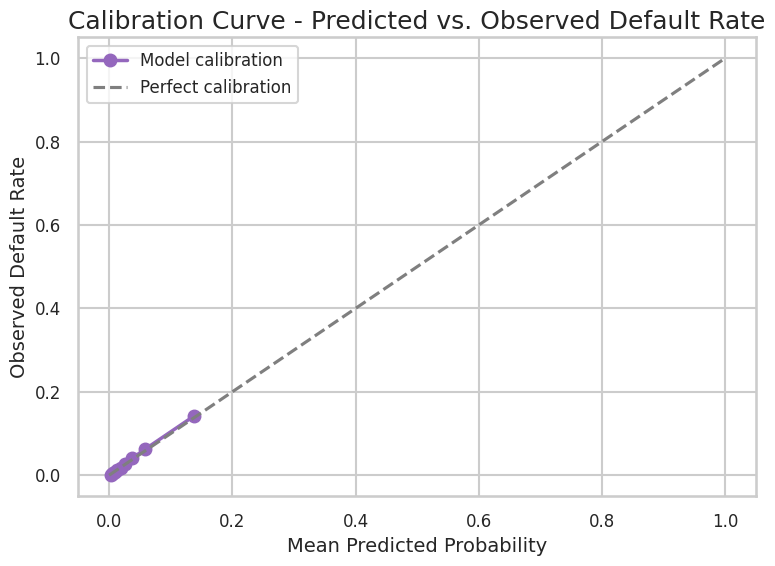

In [30]:
prob_true, prob_pred = calibration_curve(y_eval, y_proba, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(prob_pred, prob_true, marker="o", linewidth=2.5, color="#9467bd", label="Model calibration")
ax.plot([0, 1], [0, 1], linestyle="--", color="#7f7f7f", label="Perfect calibration")
ax.set_title("Calibration Curve - Predicted vs. Observed Default Rate")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Default Rate")
ax.legend(loc="upper left")
plt.tight_layout()
fig.savefig(IMAGE_DIR / "calibration_curve.png", dpi=300, bbox_inches="tight")
plt.show()


## Business Insight: Calibration Curve

Calibration shows whether predicted probabilities match observed default rates. A well-calibrated model is important when probabilities are used for pricing, credit limits, or expected-loss calculations.

**Business implication:** A model can rank applicants well but still overstate or understate absolute risk. Miscalibration can lead to incorrect pricing and capital allocation.

**Recommended action:** Before production use, validate calibration on a recent holdout period and consider probability calibration if the scores are used as direct probability estimates.


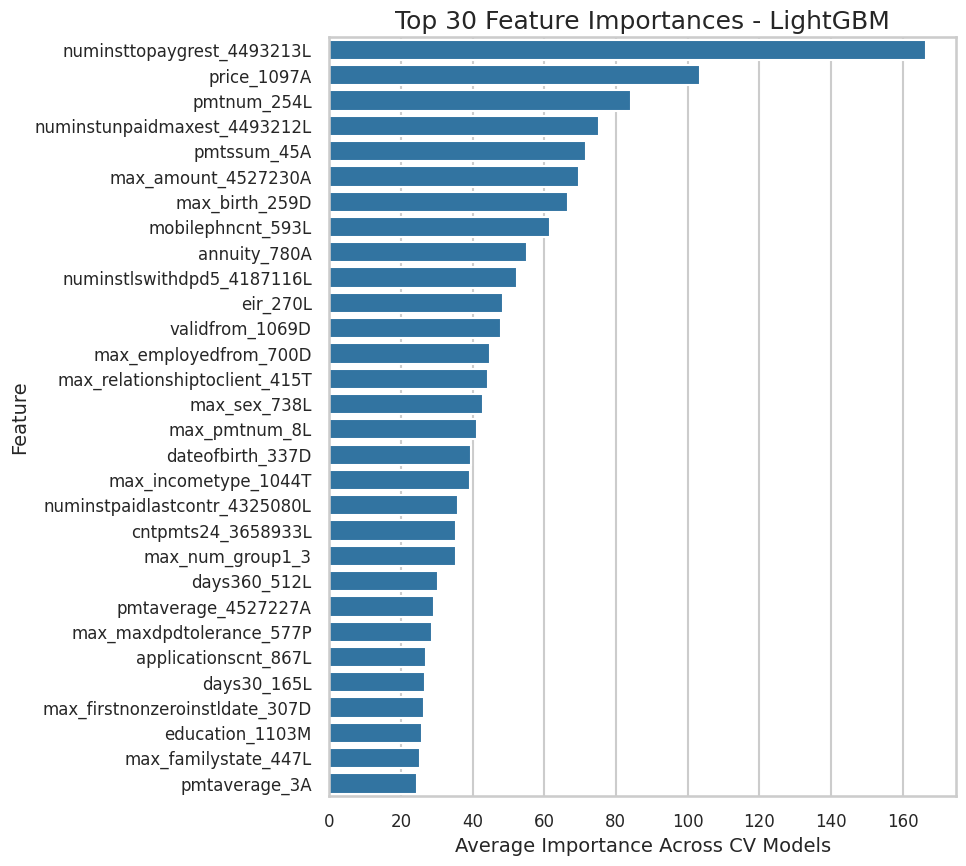

,feature,importance
151,numinsttopaygrest_4493213L,166.6
169,price_1097A,103.6
165,pmtnum_254L,84.2
153,numinstunpaidmaxest_4493212L,75.4
24,pmtssum_45A,71.8
218,max_amount_4527230A,69.8
228,max_birth_259D,66.6
130,mobilephncnt_593L,61.6
33,annuity_780A,55.2
141,numinstlswithdpd5_4187116L,52.4


In [31]:
feature_importance = (
    pd.DataFrame({
        "feature": X.columns,
        "importance": np.mean([estimator.feature_importances_ for estimator in fitted_models], axis=0),
    })
    .sort_values("importance", ascending=False)
    .head(30)
)

fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(data=feature_importance, x="importance", y="feature", color="#1f77b4", ax=ax)
ax.set_title("Top 30 Feature Importances - LightGBM")
ax.set_xlabel("Average Importance Across CV Models")
ax.set_ylabel("Feature")
plt.tight_layout()
fig.savefig(IMAGE_DIR / "feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

display(feature_importance)


## Business Insight: Feature Importance

Feature importance identifies which variables contribute most to the LightGBM split structure across cross-validation models. These variables are not necessarily causal, but they are useful for model governance and business interpretation.

**Business implication:** Important variables should be reviewed for stability, availability at decision time, regulatory acceptability, and potential proxy bias.

**Recommended action:** Use the top variables as a starting point for risk policy review, monitoring dashboards, and explainability documentation.


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


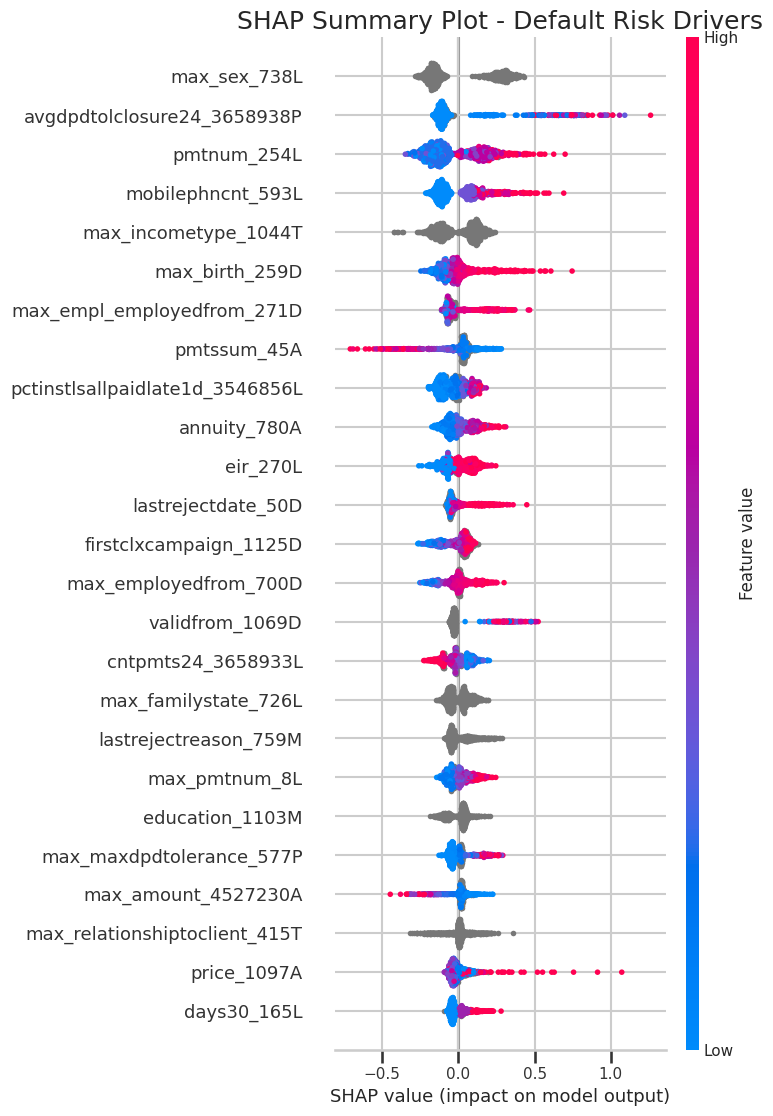

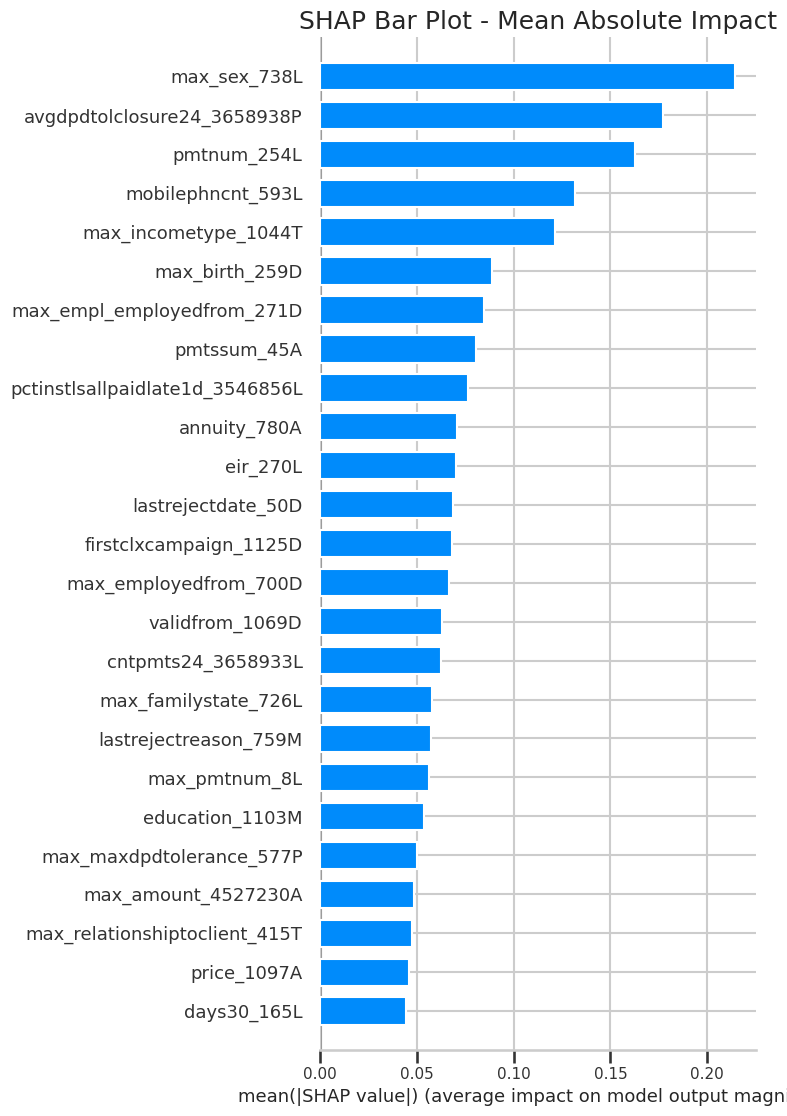

In [32]:
def is_tree_based_model(estimator):
    """Detect common tree-based estimators for SHAP explainer selection."""
    model_name = estimator.__class__.__name__.lower()
    tree_keywords = ["lgbm", "xgb", "catboost", "forest", "tree", "boost"]
    return hasattr(estimator, "booster_") or any(keyword in model_name for keyword in tree_keywords)

try:
    import shap

    shap_model = fitted_models[0]
    shap_sample = X.sample(n=min(1000, len(X)), random_state=42)

    if is_tree_based_model(shap_model):
        explainer = shap.TreeExplainer(shap_model)
        shap_values = explainer.shap_values(shap_sample)
        if isinstance(shap_values, list):
            shap_values_to_plot = shap_values[1]
        else:
            shap_values_to_plot = shap_values
    else:
        shap_background = X.sample(n=min(100, len(X)), random_state=42)
        shap_columns = shap_sample.columns
        shap_dtypes = shap_sample.dtypes

        def predict_for_kernel(data):
            data = pd.DataFrame(data, columns=shap_columns)
            for col, dtype in shap_dtypes.items():
                data[col] = data[col].astype(dtype)
            return shap_model.predict_proba(data)[:, 1]

        explainer = shap.KernelExplainer(predict_for_kernel, shap_background)
        shap_values_to_plot = explainer.shap_values(shap_sample, nsamples=100)

    shap.summary_plot(shap_values_to_plot, shap_sample, show=False, max_display=25)
    plt.title("SHAP Summary Plot - Default Risk Drivers")
    plt.tight_layout()
    plt.savefig(IMAGE_DIR / "shap_summary.png", dpi=300, bbox_inches="tight")
    plt.show()

    shap.summary_plot(shap_values_to_plot, shap_sample, plot_type="bar", show=False, max_display=25)
    plt.title("SHAP Bar Plot - Mean Absolute Impact")
    plt.tight_layout()
    plt.savefig(IMAGE_DIR / "shap_bar.png", dpi=300, bbox_inches="tight")
    plt.show()
except Exception as shap_error:
    print(f"SHAP plots were skipped because SHAP could not be completed: {shap_error}")


## Business Insight: SHAP Explainability

SHAP values estimate how each feature contributes to the model's predicted default risk for sampled applicants. The summary plot shows both direction and magnitude, while the bar plot ranks features by average impact.

**Business implication:** SHAP helps translate model behavior into language risk, compliance, and business teams can review. It also supports challenger-model comparison and model monitoring.

**Recommended action:** Use SHAP outputs in model documentation, but validate explanations with domain experts before converting them into policy rules.


In [33]:
if len(X) <= 50000:
    learning_curve_model = clone(fitted_models[0])
    lc_cv = StratifiedGroupKFold(n_splits=3, shuffle=False)

    train_sizes, train_scores, valid_scores = learning_curve(
        learning_curve_model,
        X,
        y,
        groups=weeks,
        cv=lc_cv,
        scoring="roc_auc",
        train_sizes=np.linspace(0.2, 1.0, 5),
        n_jobs=-1,
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    valid_mean = valid_scores.mean(axis=1)
    valid_std = valid_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(train_sizes, train_mean, marker="o", color="#1f77b4", label="Training ROC-AUC")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="#1f77b4", alpha=0.15)
    ax.plot(train_sizes, valid_mean, marker="o", color="#ff7f0e", label="Validation ROC-AUC")
    ax.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, color="#ff7f0e", alpha=0.15)
    ax.set_title("Learning Curve - LightGBM")
    ax.set_xlabel("Training Examples")
    ax.set_ylabel("ROC-AUC")
    ax.legend(loc="best")
    plt.tight_layout()
    fig.savefig(IMAGE_DIR / "learning_curve.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Learning curve skipped because the dataset is large for repeated cross-validation training in this notebook environment.")


Learning curve skipped because the dataset is large for repeated cross-validation training in this notebook environment.


## Business Insight: Learning Curve

The learning curve, when generated, compares training and validation ROC-AUC as more training data is used. It helps diagnose whether the model is limited by data volume, variance, or bias.

**Business implication:** If validation performance keeps improving with more data, additional recent observations may improve risk ranking. If training performance is high but validation lags, stronger regularization or feature review may be needed.

**Recommended action:** Use learning-curve behavior to decide whether to invest in more data collection, richer features, or model tuning.


# Business Recommendations

1. Use predicted default probability as a risk score rather than a simple binary label. This supports flexible policy thresholds across products, regions, and risk appetites.
2. Create score bands for automated approval, manual review, and high-risk decline queues. Borderline applicants should receive additional verification rather than an immediate rejection when business rules allow.
3. Monitor top model drivers for drift, missingness changes, and operational availability. Feature instability can reduce model reliability even when historical validation performance is strong.
4. Validate calibration before using scores for pricing or expected-loss calculations. Ranking quality and probability accuracy are related but not identical.
5. Review important variables with compliance and credit-risk teams to ensure they are explainable, permissible, and aligned with responsible lending practices.

# Future Improvements

Potential production improvements include probability calibration, model monitoring dashboards, automated data-quality checks, threshold optimization based on expected loss, challenger models, feature drift alerts, batch scoring pipelines, and deployment behind a governed decision service with audit logging.


# Prediction and Submission

The trained cross-validation ensemble is applied to the test dataset using the original submission workflow. The prediction target remains the probability of default for each `case_id`.


In [34]:
X_test = df_test.drop(columns=["WEEK_NUM"])
X_test = X_test.set_index("case_id")

X_test[['pmtcount_693L', 'pmtscount_423L', 'deferredmnthsnum_166L', 'max_credacc_transactions_402L']] = X_test[['pmtcount_693L', 'pmtscount_423L', 'deferredmnthsnum_166L', 'max_credacc_transactions_402L']].astype(float)

lgb_pred = pd.Series(model.predict_proba(X_test)[:, 1], index=X_test.index)

In [35]:
df_subm = pd.read_csv(ROOT / "sample_submission.csv")
df_subm = df_subm.set_index("case_id")

df_subm["score"] = lgb_pred

In [36]:
print("Check null: ", df_subm["score"].isnull().any())


Check null:  False


In [37]:
df_subm.head()

,score
case_id,
57543,0.017160
57549,0.027295
57551,0.006489
57552,0.012122
57569,0.067675


In [38]:
pwd

'/kaggle/working'

In [39]:
df_subm.to_csv("/kaggle/working/submission.csv")

# Executive Summary

This notebook builds a LightGBM-based loan default prediction model using the original Home Credit relational data pipeline, feature engineering logic, `StratifiedGroupKFold` validation strategy, and submission generation flow.

**Key findings:** The model produces out-of-fold probability scores that can be evaluated through ROC-AUC, precision, recall, F1, calibration, and probability-distribution diagnostics. These outputs help translate model quality into lending-policy decisions.

**Important variables:** The feature-importance and SHAP sections identify the strongest model drivers. These variables should be reviewed for business validity, stability, compliance suitability, and monitoring priority.

**Model strengths:** LightGBM is well suited to high-dimensional tabular credit data, handles nonlinear interactions, and performs efficiently across cross-validation folds. The grouped validation design supports more realistic stability assessment across weekly cohorts.

**Model limitations:** The notebook uses default LightGBM hyperparameters, a fixed threshold for classification metrics, and historical validation data. Probability calibration and threshold selection should be validated against current business objectives before production use.

**Business impact:** A reliable default-risk model can reduce credit losses, improve manual review prioritization, support responsible approvals, and help expand lending access to applicants who may be underserved by traditional scorecards.

**Production recommendations:** Deploy the model through a governed batch or real-time scoring pipeline with data validation, drift monitoring, calibration checks, model-performance dashboards, approval-threshold governance, and periodic retraining based on recent portfolio outcomes.
